<h2> A notebook exploring Classification models in Machine Learning

**Description of the data:**
A small subset of the [yelp dataset] (https://www.yelp.com/dataset).

- **`yelp_2004.csv`** contains the dataset.
- Each observation (row) in this dataset is a review of a particular business by a particular user.
- The **stars** column is the number of stars (1 through 5) assigned by the reviewer to the business. (Higher stars are better.) In other words, it is the rating of the business by the person who wrote the review.
- The **text** column is the text of the review.

**Goal:** Predict the star rating of a review using only the review text.

In [2]:
#Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import naive_bayes, linear_model, model_selection, metrics
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from wordcloud import WordCloud,STOPWORDS

In [3]:
#Load the dataset
df = pd.read_csv('yelp_2004.csv')
df.shape

(21000, 2)

##### Word Clouds
Exploring the dataset and generating the word cloud for reviews with `stars=1` and `stars=5`

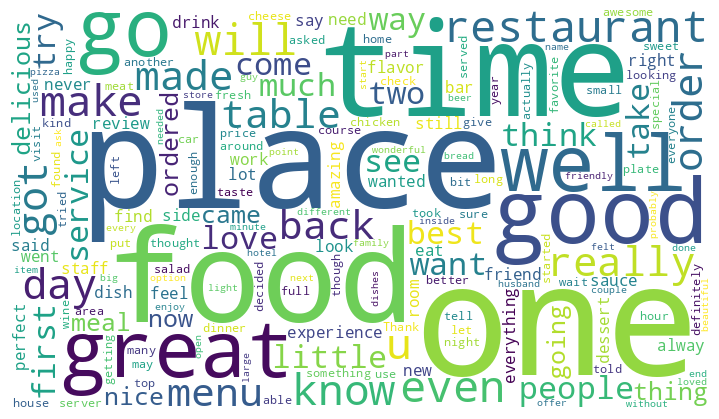

In [ ]:
#Word Cloud of 5-star reviews

#Create a new dataframe containing only 5-star reviews
five_stars = df[df['stars']==5]

#Create a string of the 5-star reviews to use as the argument for generating word cloud
str_5_stars = " ".join(review for review in five_stars['text'])

#Generate word cloud
wordcloud = WordCloud(width = 700, height = 400, background_color ='white', stopwords = STOPWORDS, min_font_size = 10).generate(str_5_stars)

#Display word cloud using matplotlib
plt.figure(figsize = (7, 4))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

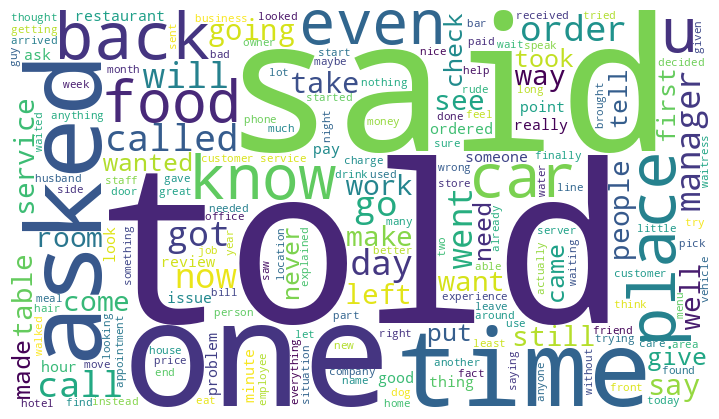

In [ ]:
#Word Cloud of 1-star reviews

#Create a new dataframe containing only 1-star reviews
one_star = df[df['stars']==1]

#Create a string of the 1-star reviews to use as the argument for generating word cloud
str_1_star = " ".join(review for review in one_star['text'])

#Generate word cloud
wordcloud = WordCloud(width = 700, height = 400, background_color ='white', stopwords = STOPWORDS, min_font_size =10).generate(str_1_star)

#Display word cloud using matplotlib
plt.figure(figsize = (7, 4))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

<b>Observation on generated word clouds:</b> The words 'good' and 'great' stand out in the 5-star review word cloud as expected.
However, most of the other words magnified in both the word clouds do not give us an insight into the words that make the reviews negative or positive. They are in fact commonly used words in English.
This could be due to the fact that the data is not preprocessed to contain *only* the words that make meaningful 1-star and 5-star reviews. The parameter stopwords is set to STOPWORDS from wordcloud is used in WordCloud() to attempt reducing the occurence of these common words (this is also the default parameter, written explicitly in the above code).

<h4> Linear Regression </h4>

Building a linear regression model to predict the stars based solely on the text feature.

Steps:
1. Split the data into train (80%) and test (20%) using random_state = 2024
2. Use [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) to generate a vector representation of the text. Use ngram_range = (1, 2) and min_df=10
3. Build a linear regression model using the default parameters.

In [6]:
#Splitting the dataframe into train and test
df_training, df_testing = model_selection.train_test_split(df, test_size=0.2, random_state=2024)

#Vectorizing only text data
vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=10)
X = vectorizer.fit_transform(df_training['text']) #fit_transform makes vectorizer learn the vocabulary of the training text and transforms it into a matrix
X_test = vectorizer.transform(df_testing['text']) #transform creates a matrix representation of the test text after the fitting of the vectorizer has been done using the train text

#Linear regression model
linear_reg = linear_model.LinearRegression()
linear_reg.fit(X,df_training['stars']) #X is the training text, y is the stars of the train set

predicted_linear = linear_reg.predict(X_test) #after the model is trained, prediction is done using the test vector

print('Train RMSE:', np.sqrt(metrics.mean_squared_error(df_training['stars'], linear_reg.predict(X))))
print('Test RMSE:', np.sqrt(metrics.mean_squared_error(df_testing['stars'], predicted_linear)))

Train RMSE: 0.007715196121217499
Test RMSE: 0.9528954240514685


From the documentation: "CountVectorizer implements both tokenization and occurrence counting in a single class"

The working of CountVectorizer: Tokenization breaks the given text into tokens (the range of tokens can be customized using the parameter ngram_range(1,2) where we include both unigrams(single words) and bigrams(pairs of consecutive words)). Occurence Counting counts the occurence of each token in the given data and a numerical matrix representation is created which contains the frequency of the tokens.

There are number of parameters that can be changed to ignore or include tokens as per our requirement.

What do `ngram_range` and `min_df` mean?

ngram_range: Gives the lower and upper values of the ngrams to be extracted from the text. eg:-(1,2) includes both unigrams(single words) and bigrams(pairs of consecutive words); (2,2) would include only bigrams.

min_df: Takes a float value between 0 and 1. It takes into consideration only the terms that occur a greater number of times (percentage) than the given threshold. In other words, it ignores the terms that have a document frequency strictly lower than the given threshold. It can also take an integer value, this denotes that the terms that occur in less than the given number of documents must be ignored.

Train RMSE: 0.007715196121217499

Test RMSE: 0.9528954240514685

Root Mean Squared Error (RMSE) is a performance indicator of the linear regression model. It measures the average difference between values predicted by a model and the actual values. The lower the RMSE, the better the model is (ideal RMSE value is 0).
We can see that the Train RMSE < Test RMSE. This is because the predictions from the Train data are better because the model has been fit using the same vector X.

<h5> 10 most important features based on the magnitude of the coefficients.

In [ ]:
#getting the coefficients of the above trained linear regression model
coefficients = linear_reg.coef_

#getting the indices of the top 10 coefficients, argsort() returns the indices of the sorted array
top_10_indices = coefficients.argsort()[-10:]

#getting the indices of the top 10 coefficients, argsort() returns the indices of the sorted array
feature_names = vectorizer.get_feature_names_out()

top_10_coefficients = pd.DataFrame({
    'Feature': [feature_names[i] for i in top_10_indices],
    'Coefficient': [coefficients[i] for i in top_10_indices]
})
#the index is directly used from top_10_indices to get the feature and coefficient of the particular token which falls in the top 10 important features
#this is possible because the index values for feature_names and coefficients are corresponding because both are fit using the same data

print(top_10_coefficients)

         Feature  Coefficient
0      instantly     0.103802
1       not just     0.104801
2         amazed     0.105526
3  stars because     0.109042
4     phenomenal     0.109542
5        chatted     0.110341
6        you won     0.112837
7       grateful     0.142508
8      right now     0.224362
9       now know     0.300316


The above generated top 10 features seem sensible as most of them are words that denote satisfaction which is what positive reviews are written for. Larger the coefficient, greater its importance is in predicting the stars. The largest coefficient is for the token 'now know' which by seeing on its own we cannot predict the stars for that review. However, 7 out of the 10 features identified denote positive sentiments which can help the model predict higher reviews.

<h5> Building 4 Lasso regression models with alpha in [0.0001, 0.001, 0.01, 0.1]

In [ ]:
#declaring a dataframe to store the output
cols = ['alpha','Train_RMSE','Model Complexity','Test_RMSE']
df_op_lasso = pd.DataFrame(columns = cols)

for power in [-4.0, -3.0, -2.0, -1.0]:
    #Lasso model with changing alpha every iteration, alpha calculated to the power of 10
    lasso_model = linear_model.Lasso(alpha=np.power(10, power),random_state=2024)
    lasso_model.fit(X, df_training['stars']) #

    #calculating the RMSE scores, the prediction using the model and train and test data is done inside the mean_squared_error function
    Train_RMSE_lasso = round(np.sqrt(metrics.mean_squared_error(df_training['stars'], lasso_model.predict(X))), 4)
    Test_RMSE_lasso = round(np.sqrt(metrics.mean_squared_error(df_testing['stars'], lasso_model.predict(X_test))), 4)

    #model complexity calculated as the number of non zero coefficients which denotes the number of features that contributed to the model training
    model_complexity_lasso = np.count_nonzero(lasso_model.coef_)

    #creating a new row and concatinating to the output dataframe
    row = {'alpha':np.power(10, power),
           'Train_RMSE':Train_RMSE_lasso,
           'Model Complexity':model_complexity_lasso,
           'Test_RMSE':Test_RMSE_lasso}
    df_op_lasso = pd.concat([df_op_lasso, pd.DataFrame([row])], ignore_index=True)

df_op_lasso

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1185.6054173171542, tolerance: 4.236702833333354
  model = cd_fast.sparse_enet_coordinate_descent(


,alpha,Train_RMSE,Model Complexity,Test_RMSE
0,0.0001,0.1644,14171,1.0392
1,0.0010,0.6620,3771,0.8604
2,0.0100,0.9127,385,0.9405
3,0.1000,1.1385,50,1.1533


Alpha determines how much we penalize the coefficients in the model. A higher alpha means stronger regularization, leading to smaller coefficient values. The lower the RMSE value, the better the model is.
It can be observed that with the increasing alpha value, the train RMSE is steadily increasing while the model complexity is decreasing.
The test RMSE values however decrease between alpha values 0.0001 and 0.001 and increase after that. RMSE values greater than 1 denote that the model could not optimize (converge) properly.

Out of all the test RMSE values to judge the best model - alpha value at 0.0001 seems to perform the best.

<h5> Building 4 Ridge regression models with alpha in [0.1, 1, 10, 100, 500, 1000]

In [7]:
#declaring a dataframe to store the reuired outputs
cols = ['alpha','Train_RMSE','Model Complexity','Test_RMSE']
df_op_ridge = pd.DataFrame(columns = cols)

#running a for loop for the models with the given alpha values
for power in [0.1,1,10,100,500,1000]:
    #Ridge model with alpha changing every loop
    ridge = linear_model.Ridge(alpha=power)
    ridge.fit(X, df_training['stars']) #fitting the model with the train vector X, and y being the star values from the split training dataframe

    #calculating the RMSE score, the prediction using the model and train and test data is done inside the mean_squared_error function
    TrainRMSE = round(np.sqrt(metrics.mean_squared_error(df_training['stars'], ridge.predict(X))), 4)
    TestRMSE = round(np.sqrt(metrics.mean_squared_error(df_testing['stars'], ridge.predict(X_test))), 4)

    if len(ridge.coef_.shape) == 1:  # Check if coefficient array is 1D
      model_complexity = np.abs(ridge.coef_[0])  # Absolute value of the coefficient
    else:
      model_complexity = np.sqrt(np.square(ridge.coef_[0][0]) + np.square(ridge.coef_[0][1]))
    #model complexity is calculated using square root of the sum of squares of the coefficients (Euclidean)
    #Ridge penalises large coefficients - higher the Euclidean distance, higher the coefficients implying greater complexity of the model.

    #creating a row with the above calculated values and adding it to the output dataframe
    row = {'alpha':power,
           'Train_RMSE':TrainRMSE,
           'Test_RMSE':TestRMSE,
           'Model Complexity':model_complexity}
    df_op_ridge = pd.concat([df_op_ridge, pd.DataFrame([row])], ignore_index=True)

print(df_op_ridge)

    alpha  Train_RMSE  Model Complexity  Test_RMSE
0     0.1      0.0077          0.029287     0.9523
1     1.0      0.0093          0.029270     0.9490
2    10.0      0.0363          0.029117     0.9366
3   100.0      0.2158          0.030332     0.8861
4   500.0      0.4686          0.031587     0.8464
5  1000.0      0.5760          0.031002     0.8440


As alpha value increases, the Train RMSE and Model complexity increase while the Test RMSE decreases. Alpha determines how much we penalize the coefficients in the model. A higher alpha means stronger regularization, leading to smaller coefficient values. The lower the RMSE value, the better the model is. The test RMSE decreasing shows that when the model has to predict using the test values it is performing better. This is because the model is is regularized more strongly at higer alpha values leading to reduction in overfitting on the training data.

While the decreasing test RMSE is a favourable outcome, the best value at 0.8440 (when alpha is 1000) is still pretty high. The ideal RMSE value is 0 or as close to 0 as possible.

<h4>Logistic Regression</h4>

Building a logistic regression model to predict the highest and lowest stars based on the text feature. 

Steps:
1. Create a new DataFrame that containings only the 5-star and 1-star reviews.
2. Split the data into train (80%) and test (20%) using random_state = 2024
3. Use [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) to generate a vector representation of the text. Use ngram_range = (1, 2) and min_df=10
4. Build a logistic regression model. Set penalty='none', max_iter=1000, random_state=2024

In [9]:
#creating a dataframe with only 1 and 5 star reviews
df_1_and_5 = pd.DataFrame(df)
df_1_and_5 = df[(df['stars']==5) | (df['stars']==1)]

#splitting the data into train and test
df_15_train, df_15_test = model_selection.train_test_split(df_1_and_5, test_size=0.2, random_state=2024)

#vectorizing the text reviews using CountVectorizer
vectorize = CountVectorizer(ngram_range=(1, 2), min_df=10)
X15 = vectorize.fit_transform(df_15_train['text'])
X15_test = vectorize.transform(df_15_test['text'])

#Logistic Regression Model with given parameters
logistic_reg = linear_model.LogisticRegression(penalty='none', max_iter=1000, random_state=2024)
logistic_reg.fit(X15,df_15_train['stars'])

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


LogisticRegression(max_iter=1000, penalty='none', random_state=2024)

Confusion matrix for train and test set

Train Set:
[[5818    0]
 [   0 3664]]
Test Set:
[[1393   34]
 [  41  903]]


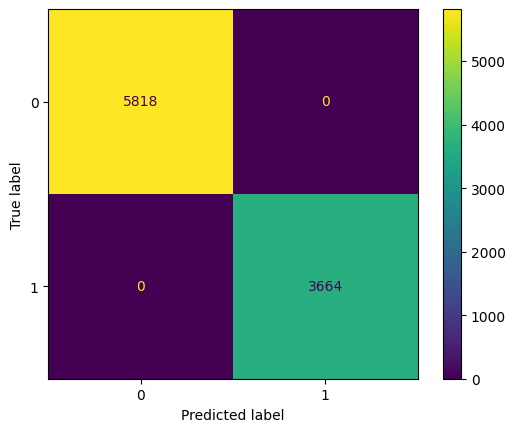

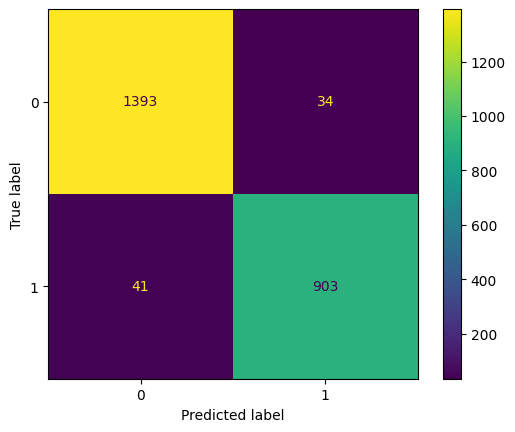

In [16]:
validated = logistic_reg.predict(X15) #predicting values using the train vector X15
print("Train Set:")
#generating the confusion matrix using the predicted train values and the actual train values
confusion_matrix_train = metrics.confusion_matrix(df_15_train['stars'], validated)
print(confusion_matrix_train)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_train)
cm_display.plot()

predicted = logistic_reg.predict(X15_test) #predicting values using the test vector
print("Test Set:")
#generating the confusion matrix comparing the test values given and predicted values of test data
confusion_matrix_test = metrics.confusion_matrix(df_15_test['stars'], predicted)
print(confusion_matrix_test)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_test)
cm_display.plot()

Observations on the generated confusion matrices:
In the training confusion matrix, the false positives and false negatives are 0. This is because the model is predicting using the same data that it was trained on.
In the test confusion matrix, we can see that the values of false positives and negatives are quite small compared to the true positives and negatives which indicates that the model is predicting well.

Building 6 L2 regularized logistic regression models with C in [0.001, 0.01, 0.1, 1, 10, 100]

In [ ]:
C = [0.001, 0.01, 0.1, 1, 10, 100]
#declaring a dataframe to store the required output
cols = ['C','Train AUC', 'Model Complexity', 'Test AUC']
df_op_l2 = pd.DataFrame(columns = cols)
#declaring a dataframe to store the values required to plot the ROC curves
df_tpr_fpr_l2 = pd.DataFrame(columns = ['fpr','tpr','y_prob'])

for c in C:
  #logistic regression models with penalty L2 and c changing every iteration
  cl2 = linear_model.LogisticRegression(C=c, penalty='l2', max_iter=1000, random_state=2024)
  cl2.fit(X15,df_15_train['stars']) #model being fit with the training data
  train_predicted = cl2.predict(X15) #model predicting the label using the training data
  tr_pred_proba = cl2.predict_proba(X15)[::,1] #probabilites of the predicted values

  test_predicted = cl2.predict(X15_test) #model predicting the label using the test data

  #calculating the train and test AUC scores
  train_AUC = metrics.roc_auc_score(df_15_train['stars'],train_predicted)
  test_AUC = metrics.roc_auc_score(df_15_test['stars'],test_predicted)
  model_complexity_l2 = np.sqrt(np.square(cl2.coef_[0][0]) + np.square(cl2.coef_[0][1]))
  #model complexity is calculated using square root of the sum of squares of the coefficients (Euclidean)
  #Ridge penalises large coefficients - higher the Euclidean distance, higher the coefficients implying greater complexity of the model.

  #adding the computed values to the dataframe for the output
  row = {'C':c,
         'Train AUC':train_AUC,
         'Test AUC':test_AUC,
         'Model Complexity':model_complexity_l2}
  df_op_l2 = pd.concat([df_op_l2, pd.DataFrame([row])], ignore_index=True)

  #calculating the probabilites of predicted labels to compute false positive and true positive rate using roc_curve()
  y_pred_proba = cl2.predict_proba(X15_test)[:,1]

  #calculating the false positive and true positive rate
  fpr, tpr, _ = metrics.roc_curve(df_15_test['stars'], y_pred_proba,pos_label=5)
  #adding computed data to the dataframe for plotting the ROC curves
  graph_row = {'fpr':fpr,
               'tpr':tpr,
               'y_prob':y_pred_proba}
  df_tpr_fpr_l2 = pd.concat([df_tpr_fpr_l2, pd.DataFrame([graph_row])],ignore_index=True)

print(df_op_l2)

         C  Train AUC  Model Complexity  Test AUC
0    0.001   0.966681          0.022751  0.941509
1    0.010   0.996927          0.048641  0.962305
2    0.100   1.000000          0.076397  0.966354
3    1.000   1.000000          0.105090  0.966526
4   10.000   1.000000          0.134761  0.968986
5  100.000   1.000000          0.164583  0.967756


Plotting the ROC curves for the six models built above.

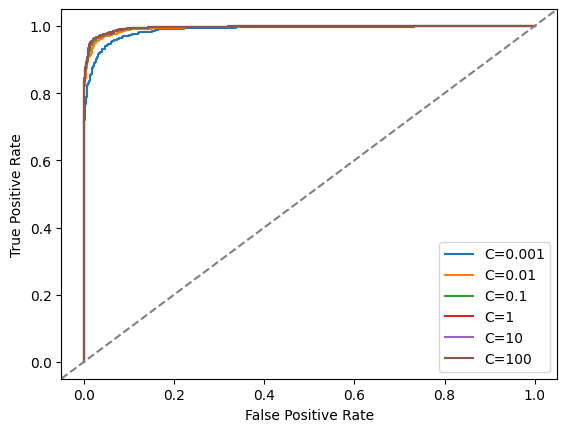

In [ ]:
# create ROC curve
for i, row in df_tpr_fpr_l2.iterrows():
    plt.plot(row['fpr'], row['tpr'], label=f'C={C[i]}')

plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.axline((0,0), slope=1,ls='--',color='gray')
plt.legend()
plt.show()

Observations from the generated AUC scores for the different C values: With increasing c values the training AUC and model complexity increase while test AUC increases until c=10 and reduces slightly when c=100.
C is the regularization parameter for logistic regression where the smaller the value the stronger the regularization which leads to the model keeping the coefficients smaller and higher c value could lead to overfitting the model because it might focus on the training data.

Best performing model: The best performing model from the above is where the test AUC is the highest at 0.968986 when c=10. The higher the AUC value, the better the model is predicting between the positive and negative classes. AUC values range between 0 to 1 with 1 being the ideal value.

The plotted curves show a satisfactory trend with it being close to the top left. There is a slight variation when c=0.001 which indicates it to be the worst performing model of all while the remaining curves seem to majorly overlap.

10 most important features based on the magnitude of the coefficients of the best performing model

In [ ]:
l2_10 = linear_model.LogisticRegression(C=10, penalty='l2', max_iter=1000, random_state=2024)
l2_10.fit(X15,df_15_train['stars'])

train_predicted = l2_10.predict(X15)
test_predicted = l2_10.predict(X15_test)

coefficients = l2_10.coef_[0]

#indices of the top 10 coefficients
#getting the indices of the top 10 coefficients, argsort() returns the indices of the sorted array
top_10_indices = coefficients.argsort()[-10:]

#feature names corresponding to the top 10 coefficients

feature_names = vectorizer.get_feature_names_out()

top_10_coefficients = pd.DataFrame({
    'Feature': [feature_names[i] for i in top_10_indices],
    'Coefficient': [coefficients[i] for i in top_10_indices]
})
#the index is directly used from top_10_indices to get the feature and coefficient of the particular token which falls in the top 10 important features
#this is possible because the index values for feature_names and coefficients are corresponding because both are fit using the same data

print(top_10_coefficients)

        Feature  Coefficient
0       date to     0.579462
1    after this     0.584861
2        cheeks     0.586254
3      long but     0.594421
4     and thank     0.638331
5     honor the     0.665481
6       bracket     0.707971
7        desert     0.712009
8  again though     0.758131
9     fish that     0.780314


The top features generated, while being meaningful do not offer much insight into the positive or negative review it could be a part of. These tokens could fall into either category.

Building 6 L1 regularized logistic regression models with C in [0.001, 0.01, 0.1, 1, 10, 100]

In [ ]:
C = [0.001, 0.01, 0.1, 1, 10, 100]
#declaring dataframes to store the required output and values for plotting ROC curves
cols = ['C','Train AUC', 'Model Complexity', 'Test AUC']
df_op_l1 = pd.DataFrame(columns = cols)
df_tpr_fpr_l1 = pd.DataFrame(columns = ['fpr','tpr','y_prob'])

for c in C:
  #logistic regression models with penalty L1, c value changing every iteration
  #solver is set to liblinear as the default solver lbfgs does not support L1 penalties
  cl1 = linear_model.LogisticRegression(C=c, penalty='l1', max_iter=1000, random_state=2024, solver='liblinear')
  cl1.fit(X15,df_15_train['stars'])

  train_predicted = cl1.predict(X15)
  test_predicted = cl1.predict(X15_test)

  #computing the AUC scores for test and train data
  train_AUC_l1 = metrics.roc_auc_score(df_15_train['stars'],train_predicted)
  test_AUC_l1 = metrics.roc_auc_score(df_15_test['stars'],test_predicted)
  #model complexity calculated as the number of non zero coefficients which denotes the number of features that contributed to the model training
  model_complexity_l1 = np.count_nonzero(cl1.coef_)

  #adding the computed values to the dataframe for output
  row = {'C':c,
         'Train AUC':train_AUC_l1,
         'Test AUC':test_AUC_l1,
         'Model Complexity':model_complexity_l1}
  df_op_l1 = pd.concat([df_op_l1, pd.DataFrame([row])], ignore_index=True)

  #calculating the probabilites of predicted labels to compute false positive and true positive rate using roc_curve()
  y_pred_proba = cl1.predict_proba(X15_test)[:,1]
  #calculating the false positive and true positive rate
  fpr, tpr, _ = metrics.roc_curve(df_15_test['stars'], y_pred_proba,pos_label=5)
  #adding computed data to the dataframe for plotting the ROC curves
  graph_row = {'fpr':fpr,
               'tpr':tpr,
               'y_prob':y_pred_proba}
  df_tpr_fpr_l1 = pd.concat([df_tpr_fpr_l1, pd.DataFrame([graph_row])],ignore_index=True)

print(df_op_l1)

         C  Train AUC Model Complexity  Test AUC
0    0.001   0.821047               18  0.809144
1    0.010   0.922974               92  0.910512
2    0.100   0.977639              499  0.959664
3    1.000   1.000000             1023  0.961791
4   10.000   1.000000             1383  0.961425
5  100.000   1.000000             3050  0.965295


Ploting the ROC curves for the six models built

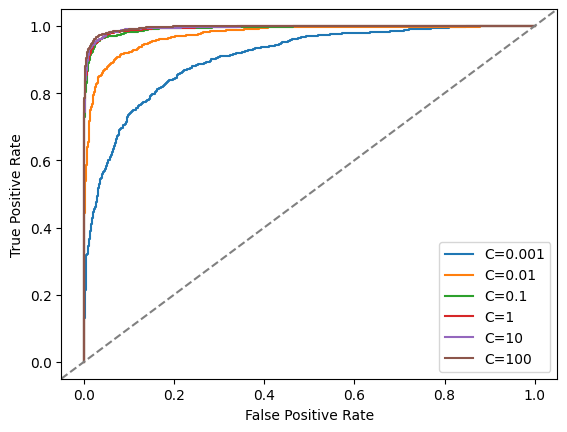

In [ ]:
#ROC curve
for i, row in df_tpr_fpr_l1.iterrows():
    plt.plot(row['fpr'], row['tpr'], label=f'C={C[i]}')

plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.axline((0,0), slope=1,ls='--',color='gray')
plt.legend()
plt.show()

Observations from the generated AUC scores for the different C values: The train AUC and model complexity values increase along with increase in C value. The same is observed for test AUC values as well until it reaches c=1 where it decreases by 0.000366 after which it increases again with increasing C value. C is the regularization parameter for logistic regression where the smaller the value the stronger the regularization which leads to the model keeping the coefficients smaller and higher c value could lead to overfitting the model because it might focus on the training data.

Best performing model: The best performing model from the above is where the test AUC is the highest at 0.965295 when c=100. The higher the AUC value, the better the model is predicting between the positive and negative classes. AUC values range between 0 to 1 with 1 being the ideal value. C is the regularization parameter for logistic regression where the smaller the value the stronger the regularization which leads to the model keeping the coefficients smaller and higher c value could lead to overfitting the model because it might focus on the training data.

The plotted curves show a satisfactory trend with the curve being towards the top left. We can see a greater gap between the c=0.001 and c=0.01 values which denote that these perform slightly worse than the other three c values which are overlapping.

Listing the 10 most important features based on the magnitude of the coefficients of the best performing model.

In [ ]:
#training the best performing model at C=100
l1_100 = linear_model.LogisticRegression(C=100, penalty='l1', max_iter=1000, random_state=2024, solver='liblinear')
l1_100.fit(X15,df_15_train['stars'])

train_predicted = l1_100.predict(X15)
test_predicted = l1_100.predict(X15_test)

coefficients = l1_100.coef_[0]

#indices of the top 10 coefficients
top_10_indices = coefficients.argsort()[-10:]

#feature names corresponding to the top 10 coefficients
feature_names = vectorizer.get_feature_names_out()

top_10_coefficients = pd.DataFrame({
    'Feature': [feature_names[i] for i in top_10_indices],
    'Coefficient': [coefficients[i] for i in top_10_indices]
})

print(top_10_coefficients)

        Feature  Coefficient
0          cant     1.301742
1     not using     1.321940
2   driving and     1.370409
3  dinner table     1.458068
4  jerk chicken     1.582157
5          crop     1.584533
6      least at     1.641620
7       antioch     1.846486
8    can really     1.891763
9     come more     2.866192


The top features generated, while being meaningful do not offer much insight into the positive or negative review it could be a part of. 8 out of 10 tokens could fall into either category. However the 9th and 10th tokens seem to denote a negative expression which could indicate that they could be a part of a lower rating.

<h4>Naive Bayes Classifier</h4>

Building a Naive Bayes model to predict the stars based on the text feature. 
Reusing the previous train and test datasets and vectorized features. Using default parameters for the MultinomialNB model.

In [22]:
#Multinomial Naive Bayes Model with default parameters
mnb = naive_bayes.MultinomialNB()

#training the model with X15 - the vector with training data from 1 & 5 star reviews
mnb.fit(X15,df_15_train['stars'])

#predicting the values using X15_test vector
predict_nb = mnb.predict(X15_test)

#accuracy is checked with the predicted values and the star values of the test data
print('Accuracy of Multinomial Naive Bayes: ', metrics.accuracy_score(df_15_test['stars'], predict_nb))

Accuracy of Multinomial Naive Bayes:  0.8954027836355968


Confusion matrices on both train and test sets

Train Set:
[[5372  446]
 [ 405 3259]]
Test Set:
[[1322  105]
 [ 143  801]]


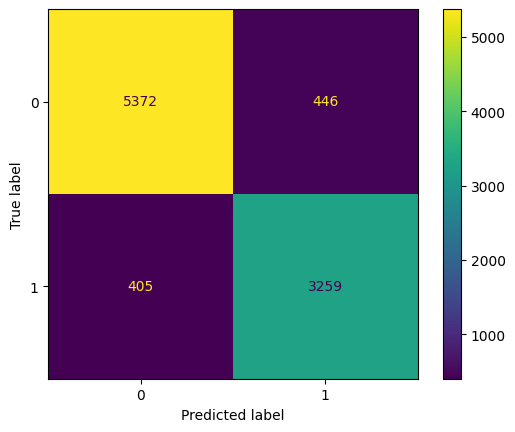

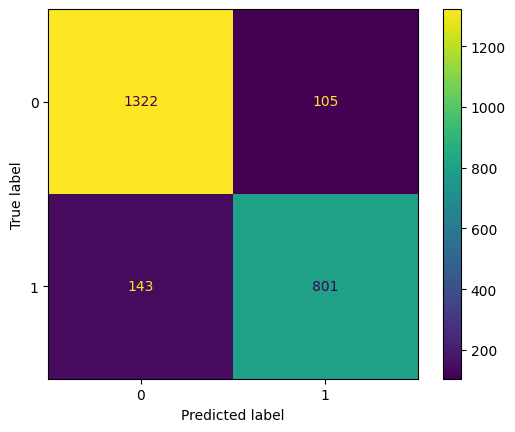

In [23]:
validated_nb = mnb.predict(X15) #Predicting values using the training vector
print("Train Set:")
#Generating the confusion matrix comparing the train values and predicted values of training data
confusion_matrix_train_nb = metrics.confusion_matrix(df_15_train['stars'], validated_nb)
print(confusion_matrix_train_nb)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_train_nb)
cm_display.plot()

predicted_nb = mnb.predict(X15_test) #Predicting values using the test vector
print("Test Set:")
#Generating the confusion matrix comparing the test values given and predicted values of test data
confusion_matrix_test_nb = metrics.confusion_matrix(df_15_test['stars'], predicted_nb)
print(confusion_matrix_test_nb)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_test_nb)
cm_display.plot()

Observation from the confusion matrices: We can see the false predictions seem to be high in both the test and train sets. For the test set, this can be attributed to the model not being trained with a diversified dataset that contains features in the test dataset leading to the model not being able to predict accurately.

Calculating which 10 tokens are the most predictive of **5-star reviews**, and which 10 tokens are the most predictive of **1-star reviews**.

Naive Bayes automatically counts the number of times each token appears in each class, as well as the number of observations in each class. You can access these counts via the `feature_count_` and `class_count_` attributes of the Naive Bayes model object.

In [25]:
#creating a dataframe for the required output for 1 & 5 star reviews
df5_top10 = pd.DataFrame(columns = ['token','predictiveness in 5 star reviews'])
df1_top10 = pd.DataFrame(columns = ['token','predictiveness in 1 star reviews'])

#the log probabilities of all features are retrieved from the NB model
feature_log_prob = mnb.feature_log_prob_
#all names of features are retrieved from the vectorizer
feature_names = vectorize.get_feature_names_out()
#the indices of the top 10 1&5 star reviews are stored in the below lists using argsort and taking the highest values of log probabilities
top_10_5_star_indices = feature_log_prob[1].argsort()[-10:][::-1]
top_10_1_star_indices = feature_log_prob[0].argsort()[-10:][::-1]

#the predictiveness metric used is the probability of the feature occuring which is calculated by exponentiating the log probability values: e^(log c) = c
# 5-star reviews
for i in top_10_5_star_indices:
  P_5 = np.exp(feature_log_prob[1][i])
  row = { 'token':feature_names[i],
           'predictiveness in 5 star reviews': P_5}
  df5_top10 = pd.concat([df5_top10, pd.DataFrame([row])], ignore_index=True)

# 1-star reviews
for i in top_10_1_star_indices:
  P_1 = np.exp(feature_log_prob[0][i])
  row = { 'token':feature_names[i],
          'predictiveness in 1 star reviews': P_1}
  df1_top10 = pd.concat([df1_top10, pd.DataFrame([row])], ignore_index=True)

print("Top 10 tokens for 5-star reviews:")
print(df5_top10)
print("\nTop 10 tokens for 1-star reviews:")
print(df1_top10)

Top 10 tokens for 5-star reviews:
  token  predictiveness in 5 star reviews
0   the                          0.032319
1   and                          0.022669
2    to                          0.016379
3    of                          0.012084
4   was                          0.010140
5    it                          0.009543
6    in                          0.008233
7  that                          0.007210
8   for                          0.006788
9    is                          0.006738

Top 10 tokens for 1-star reviews:
  token  predictiveness in 1 star reviews
0   the                          0.030118
1    to                          0.020608
2   and                          0.019835
3   was                          0.011018
4  that                          0.009284
5    of                          0.008637
6    it                          0.008306
7    my                          0.007940
8    in                          0.007375
9   for                          0.006699


The above generated tokens do not make sense to help predict if they occur in positive or negative reviews. It can be observed that they are mostly the same words for both ratings we considered, and they are very commonly used words in English while not adding much value to the prediction of what type of sentence they are a part of.